Explicitly highlight the improved outcomes specifically attributable to the new cloud cover scheme

In [21]:
import psyplot.project as psy
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

base_path = '/work/bd1179/b309170/esmvaltool_output/from_swiftbrowser'

#### Comparison; where are the biggest differences?

In [22]:
paths = {}

# icona_from_iconaml
paths['icon_nat'] = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927'

# iconaml_from_icona
# paths['icon_ml'] = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_iconaml_from_icona_20yrs'

# paths['icon_nat'] = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs/'
paths['icon_ml'] = '/work/bd1179/b309275/icon-ml_models/icon-a-ml_for_Arthur/experiments/ag_atm_amip_r2b5_cov15_tuned_Arthur_long/'

keys = list(paths.keys())

In [23]:
# Start with 2D data
data_2d = {}
for key in keys:
    # All 2D data
    data_2d[key] = xr.open_mfdataset(paths[key] + '/*atm_2d_ml*.nc')

# We are interested in the difference of ICON-ML and ICON
data_2d['icon_diff'] = data_2d['icon_ml'] - data_2d['icon_nat']

/tmp/ipykernel_1050792/1844295996.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  data_2d[key] = xr.open_mfdataset(paths[key] + '/*atm_2d_ml*.nc')
/tmp/ipykernel_1050792/1844295996.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  data_2d[key] = xr.open_mfdataset(paths[key] + '/*atm_2d_ml*.nc')


In [24]:
# Exclude time steps
DS_excluded = data_2d['icon_diff'].isel(time=slice(1, None))  # Removes the first time step

rel_diffs = {}

for var_name in DS_excluded.data_vars:
    if var_name in ['clon_bnds', 'clat_bnds']:
        continue

    # Compute the temporal mean for each variable (over the 'time' dimension)
    temporal_mean = getattr(DS_excluded, var_name).mean(dim='time')

    # Compute the overall mean for each variable
    overall_mean = getattr(data_2d['icon_nat'].isel(time=slice(1, None)), var_name).mean()

    # Compute the relative measure (temporal mean divided by overall mean)
    rel_diffs[var_name] = temporal_mean / overall_mean

In [25]:
# Load some 2D nc-file as a template for plotting
icon_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments'
file_nc = icon_path + '/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly_atm_2d_ml_19790501T000000Z.nc'
file_template = xr.open_dataset(file_nc)

# Coordinates are not fully recognized by xarray so that we have to add some manually 
coordlist = ["vertices_latitude", "vertices_longitude", "clat_bnds", "clon_bnds"]
file_template = file_template.set_coords([coord for coord in file_template.data_vars if coord in coordlist])

##### ICON-ML vs ICON-A 2D variables, relative differences

<Figure size 2000x2500 with 0 Axes>

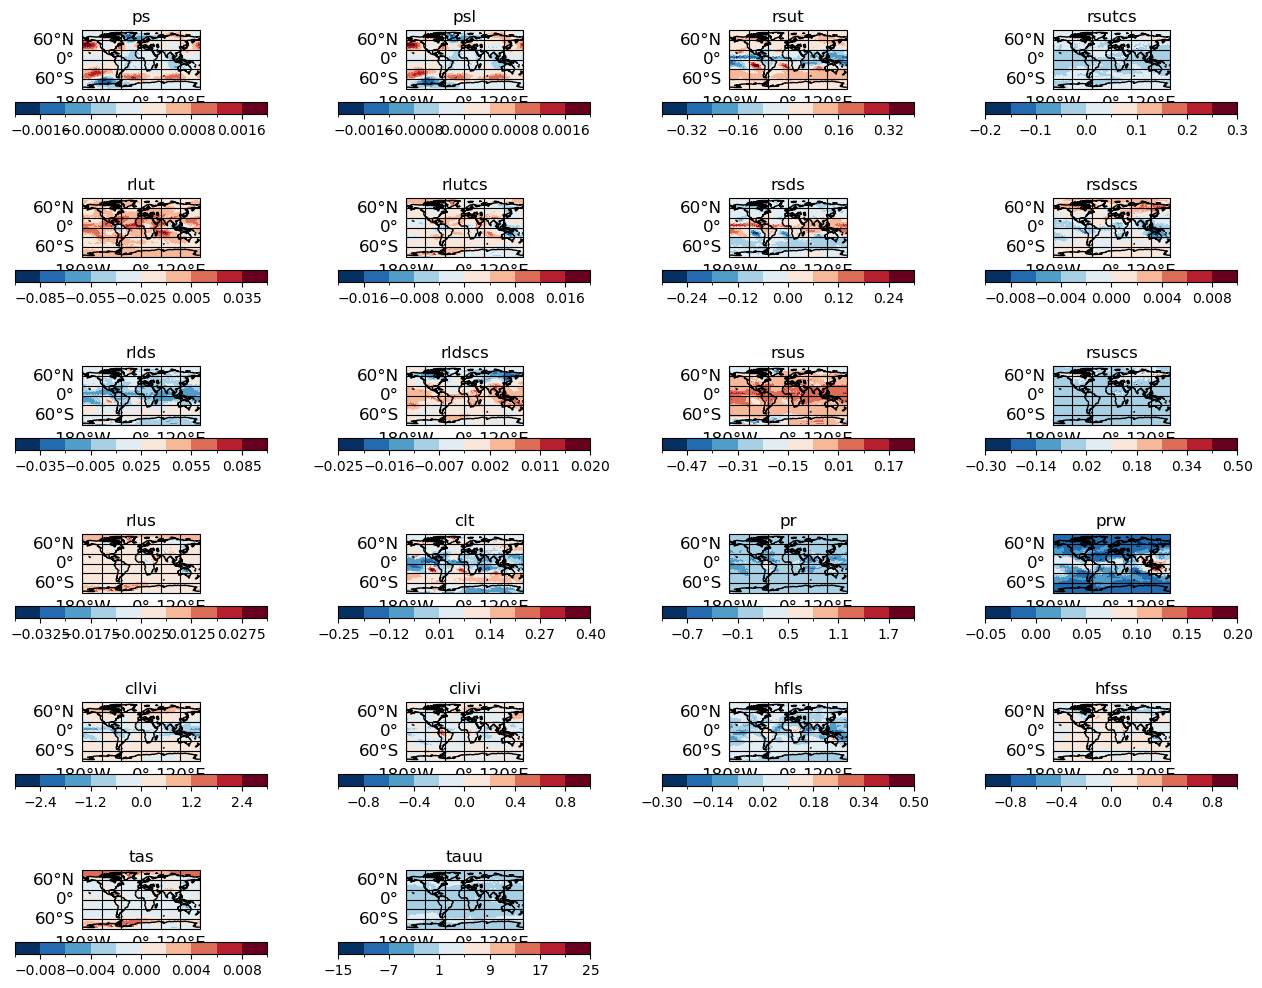

In [26]:
# Variables to loop through
all_vars = list(rel_diffs.keys())
n_plots = len(all_vars)

plt.figure(figsize=(20, 25))

# Define subplots 
ax = list(psy.multiple_subplots(rows=n_plots//4 + 1, cols=4, n=n_plots-1, for_maps=True))

plot_ind = 0
for var in all_vars:
    if var == 'rsdt': # Is all 0
        continue
    file_template.clt.values[0] = rel_diffs[var].values
    psy.plot.mapplot(file_template, name='clt', title=var, time = [0], ax = ax[plot_ind], cmap='RdBu_r')
    plot_ind = plot_ind + 1

plt.subplots_adjust(hspace=1, wspace=0.2)

Focusing in on the largest relative differences

<Figure size 1500x1000 with 0 Axes>

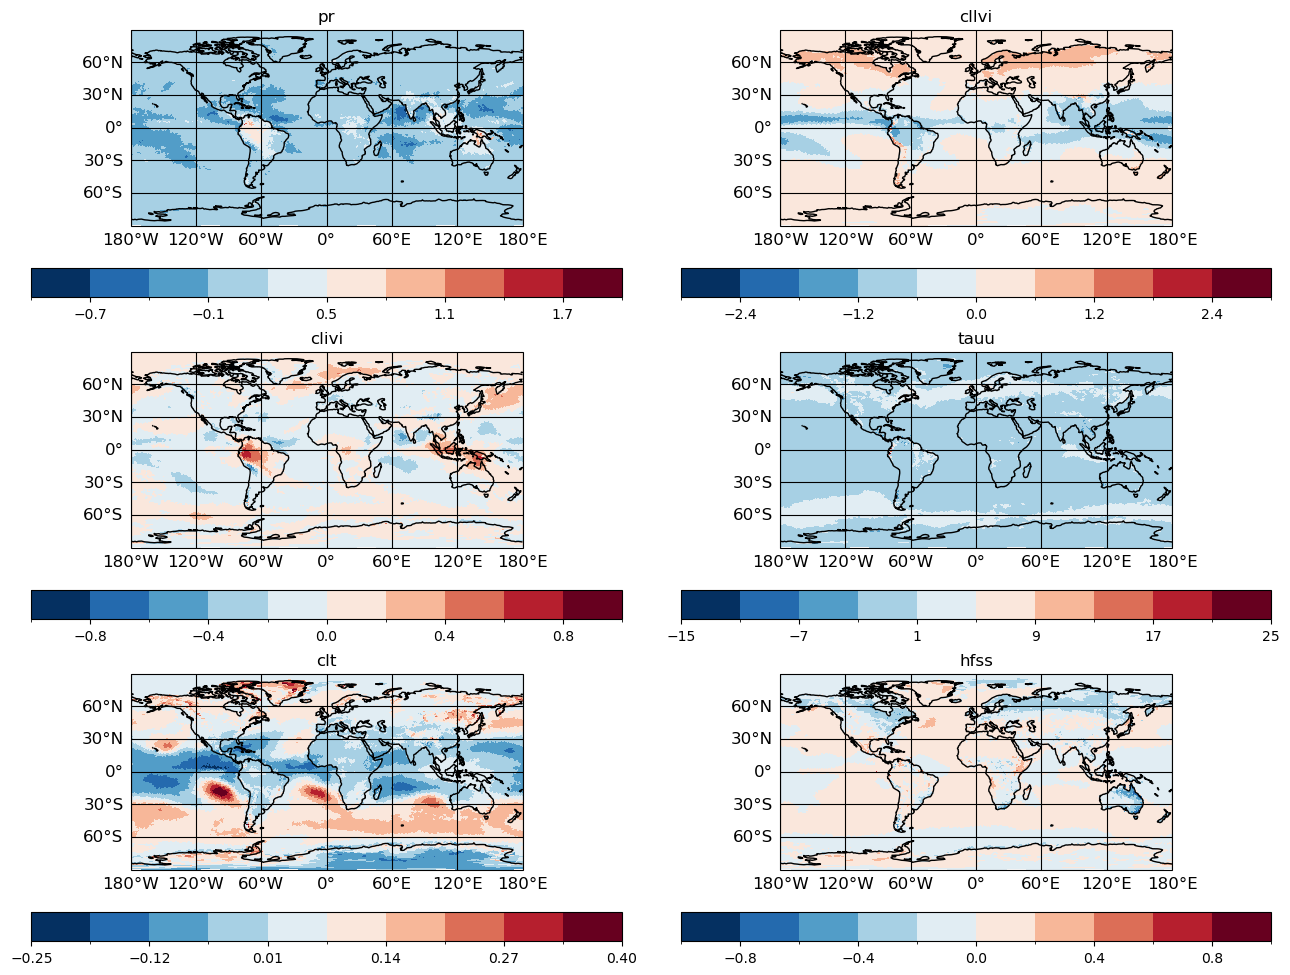

In [27]:
# Variables to loop through
all_vars = list(rel_diffs.keys())
n_plots = len(all_vars)

plt.figure(figsize=(15, 10))

# Define subplots 
ax = list(psy.multiple_subplots(rows=3, cols=2, n=6, for_maps=True))

plot_ind = 0
for var in ['pr', 'cllvi', 'clivi', 'tauu', 'clt', 'hfss']:
    if var == 'rsdt': # Is all 0
        continue
    file_template.clt.values[0] = rel_diffs[var].values
    psy.plot.mapplot(file_template, name='clt', title=var, time = [0], ax = ax[plot_ind], cmap='RdBu_r')
    plot_ind = plot_ind + 1

plt.subplots_adjust(hspace=0.15, wspace=0.1)

#### Bias plots of ICON-ML vs ICON-A of different variables
Variables considered so far: clt, pr, swcre, lwcre

**First we need to get the numbers from the esmvaltool evaluation runs**

--> Not needed for ICON-A this time as those are stored in our experiments folder...

##### Cloud Cover

<xarray.DataArray 'bias_clt' ()> Size: 8B
array(45.66965103)
Coordinates:
    time     datetime64[ns] 8B ...


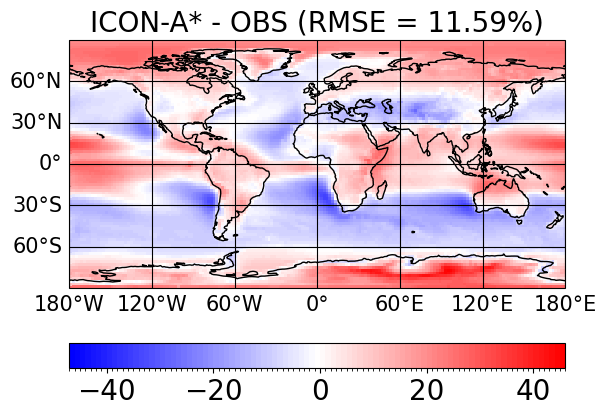

In [30]:
# Define subplots 
# ax = list(psy.multiple_subplots(rows=1, cols=1, n=1, for_maps=True))

# Second subplot: Plotting ICON data
for plot_ind in range(1):
    
    # if plot_ind == 0:
    #     # OBS
    #     path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927/output_iconeval/ag_atm_amip_r2b5_cov15_tuned_Arthur_long_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_20251020_080909UTC/esmvaltool_output/recipe_clouds_maps_20251020_081101/work/maps_clt/plot'
    #     psy.plot.mapplot('%s/map_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_clt_ICON_Amon_top_right.nc'%path, ax = ax[plot_ind],
    #                     name='clt', title='OBS', cmap='Blues_r', bounds = np.arange(0,100.1), cticks=np.arange(0, 100.1, 20), cticksize=20, titlesize=20, grid_labelsize=15)
    if plot_ind == 0:
        # ICON-ML from ICON-A
        path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927/output_iconeval/ag_atm_amip_r2b5_cov15_tuned_Arthur_long_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927_ag_atm_amip_r2b5_iconaml_from_icona_20yrs_ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_20251020_080909UTC/esmvaltool_output/recipe_clouds_maps_20251020_081101/work/maps_clt/plot'
        data = xr.open_dataset('%s/map_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927_clt_ICON_Amon_bottom.nc'%path)
        print(np.max(np.abs(data.bias_clt)))
        rmse = 11.59 # Be careful NOT to take the sqrt_mean here as the data is in latlon (180/90). For separate computation (not from the URL above) see next line.
        psy.plot.mapplot('%s/map_ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927_clt_ICON_Amon_bottom.nc'%path, 
                        name='bias_clt', title='ICON-A* - OBS (RMSE = %.2f%s)'%(rmse, '%%'), cmap='bwr', cticksize=20, bounds = np.arange(-47,47), cticks=np.arange(-40, 60, 20), titlesize=20, grid_labelsize=15)
    # elif plot_ind == 2:
    #     # Automatically tuned ICON-A
    #     path = '/home/b/b309170/bd1179_work/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_20241202_141113UTC/esmvaltool_output/recipe_clouds_maps_20241202_141300/work/maps_clt/plot'
    #     data = xr.open_dataset('%s/map_ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_clt_ICON_Amon_bottom.nc'%path)
    #     print(np.max(np.abs(data.unknown)))
    #     # From https://swiftbrowser.dkrz.de/objects/iconeval/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs/recipe_clouds_maps_20241206_115204/plots/maps_clt/plot/
    #     rmse = 11.66
    #     psy.plot.mapplot('%s/map_ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_clt_ICON_Amon_bottom.nc'%path, ax = ax[plot_ind],
    #                     name='unknown', title='ICON-A (at.) - OBS (RMSE = %.2f%s)'%(rmse, '%%'), cmap='bwr', bounds = np.arange(-47,47), cticks=np.arange(-40, 60, 20), titlesize=20, grid_labelsize=15)

##### Preprocess obs and set bounds

In [35]:
import subprocess

def remap_esacci_var(var_name):
    ## Remaps ESACCI data and returns the remapped dataset

    # Have rsdt, rlutcs, rsut, rlut, rsutcs, clivi, rlus, cltStderr, rsus, clwvi, clt, rsuscs, lwp at our disposition    
    esacci_rad_file="/work/bd0854/DATA/ESMValTool2/OBS/Tier2/ESACCI-CLOUD/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_%s_198201-201612.nc"%var_name
    some_iconml_file="/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_atm_2d_ml_19810101T000000Z.nc"
    target_file_esacci="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_%s_198201-201612_r2b5.nc"%var_name
    target_file_int="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_%s_198201-201612_r2b5_int.nc"%var_name
    target_file_int2="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_%s_198201-201612_r2b5_int2.nc"%var_name

    subprocess.run('module load cdo', check=True, shell=True)
    subprocess.run(['cdo','seltimestep,1/216', esacci_rad_file, target_file_int2], check=True) # Select proper timerange (up to and including 2000)
    subprocess.run(['cdo','timmean', target_file_int2, target_file_int], check=True)
    subprocess.run(['cdo', 'remapcon,' + some_iconml_file, target_file_int, target_file_esacci], check=True)
    subprocess.run(['rm', target_file_int], check=True)
    subprocess.run(['rm', target_file_int2], check=True)

    # Load preprocessed OBS data
    obs_rad = getattr(xr.open_dataset(target_file_esacci), var_name)[0]

    return obs_rad

def remap_isccp_var(var_name):
    ## Remaps ISCCP rad. data and returns the remapped dataset

    # Have rlut, rsut, alb, prw, ps, rsutcs, rlutcs, rsdt, rsds, rlus, rlds at our disposition    
    isccp_rad_file="/work/bd0854/DATA/ESMValTool2/OBS/Tier2/ISCCP-FH/OBS_ISCCP-FH_sat_v0_Amon_%s_198401-201612.nc"%var_name
    some_iconml_file="/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs/ag_atm_amip_r2b5_auto_tuned_baseline_20yrs_atm_2d_ml_19810101T000000Z.nc"
    target_file_isccp="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ISCCP-FH_sat_v0_Amon_%s_198401-201612_r2b5.nc"%var_name
    target_file_int="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ISCCP-FH_sat_v0_Amon_%s_198401-201612_r2b5_int.nc"%var_name
    target_file_int2="/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ISCCP-FH_sat_v0_Amon_%s_198401-201612_r2b5_int2.nc"%var_name

    subprocess.run('module load cdo', check=True, shell=True)
    subprocess.run(['cdo','seltimestep,1/196', isccp_rad_file, target_file_int2], check=True) # Select proper timerange (up to and including 2000)
    subprocess.run(['cdo','timmean', target_file_int2, target_file_int], check=True)
    subprocess.run(['cdo', 'remapcon,' + some_iconml_file, target_file_int, target_file_isccp], check=True)
    subprocess.run(['rm', target_file_int], check=True)
    subprocess.run(['rm', target_file_int2], check=True)

    # Load preprocessed OBS data
    obs_rad = getattr(xr.open_dataset(target_file_isccp), var_name)[0]

    return obs_rad

def preprocess_obs(var_name = 'rlut'):
    '''
        Get observations for radiation.
    '''
    ## OBS data. Load preprocessed OBS data
    if var_name in ['rlut', 'rsut']: # ESACCI + ISCCP as OBS
        obs_rad1 = remap_esacci_var(var_name)
        obs_rad2 = remap_isccp_var(var_name)
    elif var_name == 'lwcre':
        # ESACCI
        rlutcs = remap_esacci_var('rlutcs')
        rlut = remap_esacci_var('rlut')
        obs_rad1 = rlutcs - rlut
        # ISCCP
        rlutcs = remap_isccp_var('rlutcs')
        rlut = remap_isccp_var('rlut')
        obs_rad2 = rlutcs - rlut
    elif var_name ==  'swcre':
        # ESACCI
        rsutcs = remap_esacci_var('rsutcs')
        rsut = remap_esacci_var('rsut')
        obs_rad1 = rsutcs - rsut
        # ISCCP
        rsutcs = remap_isccp_var('rsutcs')
        rsut = remap_isccp_var('rsut')
        obs_rad2 = rsutcs - rsut
    elif var_name in ['clivi', 'lwp']: # Only consider ESACCI as OBS
        obs_rad1 = remap_esacci_var(var_name)
        obs_rad2 = obs_rad1 
    return (obs_rad1 + obs_rad2)/2

# Great methods to automatically set proper bounds and cticks!
def set_cticks(data, div=False):
    # Assuming max >= 0
    max = float(np.max(data))
    min = float(np.min(data))
    if div:
        max = np.maximum(np.abs(min), np.abs(max))
        if max > 50:
            max = int(np.ceil(max))
        min = -max
    cticks = np.arange(min, max+max/100, (max - min)/5)
    cticks = [float('%.1f'%cticks[i]) for i in range(len(cticks))]
    return cticks

def set_bounds(data, div=False):
    max = np.max(data)
    min = np.min(data)
    if div:
        max = np.maximum(np.abs(min), np.abs(max))
        min = -max
    # Bounds should be chosen such that the max and min ctick are barely included
    min_ctick = set_cticks(data, div=div)[0]
    max_ctick = set_cticks(data, div=div)[-1]
    bounds = np.linspace(min_ctick - np.abs(min_ctick)/100, max_ctick+max_ctick/100, 100)
    return bounds

##### LW Radiation

psyplot.project.Project([    arr68: 1-dim DataArray of clt, with (ncells)=(81920,), time=1.979e+07])

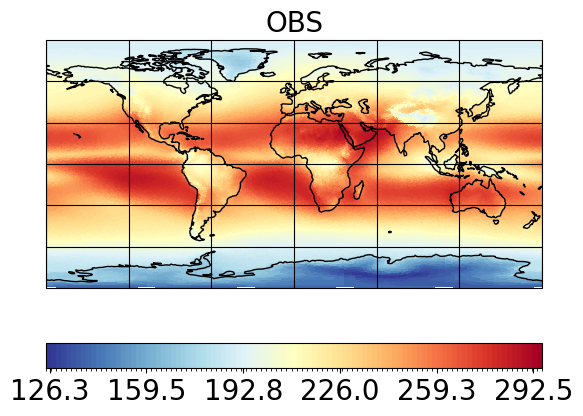

In [36]:
# Preprocess and load OBS data
# obs_avrg = preprocess_obs('rlut')
obs_avrg = xr.open_dataset("/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_rlut_198201-201612_r2b5.nc").rlut[0] 

# Load some 2D nc-file as a template for plotting
icon_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments'
file_nc = icon_path + '/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly_atm_2d_ml_19790501T000000Z.nc'
file_template = xr.open_dataset(file_nc)

# Coordinates are not fully recognized by xarray so that we have to add some manually 
coordlist = ["vertices_latitude", "vertices_longitude", "clat_bnds", "clon_bnds"]
file_template = file_template.set_coords([coord for coord in file_template.data_vars if coord in coordlist])

# Plot LW radiation
file_template.clt.values[0] = obs_avrg
psy.plot.mapplot(file_template, name='clt', time = [0], title='OBS', cmap='RdYlBu_r', grid_labels = 0, bounds = set_bounds(obs_avrg), cticks=set_cticks(obs_avrg), titlesize=20, grid_labelsize=15, cticksize=20)

cdo    remapcon: YAC first order conservative weights from lonlat (720x360) to unstructured (81920) grid
cdo    remapcon: YAC first order conservative weights from lonlat (360x180) to unstructured (81920) grid, with source mask (64788)


/tmp/ipykernel_1050792/2054793374.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  icona_from_iconaml_rlut_data = xr.open_mfdataset(data_path + '*atm_2d_ml*.nc').rlut[2:]


48.08574
RMSE = 8.1631


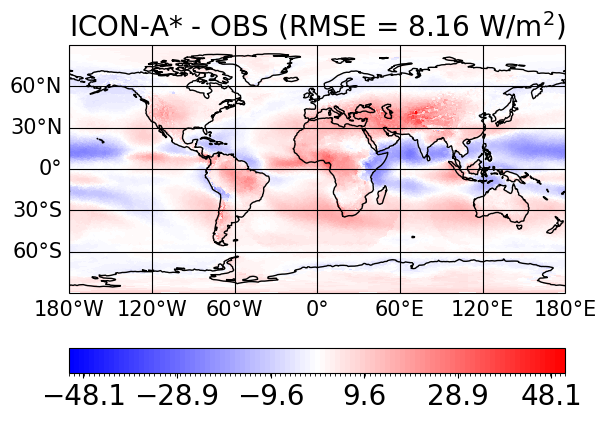

In [40]:
# Preprocess and load OBS data
obs_avrg = preprocess_obs('rlut')

data_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927/'

icona_from_iconaml_rlut_data = xr.open_mfdataset(data_path + '*atm_2d_ml*.nc').rlut[2:]
icona_from_iconaml_rlut_data_avrg = icona_from_iconaml_rlut_data.mean('time')

# Load some 2D nc-file as a template for plotting
icon_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments'
file_nc = icon_path + '/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly_atm_2d_ml_19790501T000000Z.nc'
file_template = xr.open_dataset(file_nc)

# Coordinates are not fully recognized by xarray so that we have to add some manually 
coordlist = ["vertices_latitude", "vertices_longitude", "clat_bnds", "clon_bnds"]
file_template = file_template.set_coords([coord for coord in file_template.data_vars if coord in coordlist])

# Plot LW radiation
file_template.clt.values[0] = icona_from_iconaml_rlut_data_avrg - obs_avrg
rmse = np.sqrt(np.mean((file_template.clt.values[0])**2))
print(np.max(np.abs(file_template.clt.values[0])))
print('RMSE = %.4f'%rmse)
plot = psy.plot.mapplot(file_template, name='clt', time = [0], title=r'ICON-A* - OBS (RMSE = %.2f W/m$^2$)'%rmse, cmap='bwr', bounds = np.linspace(-51,51,100), \
                 cticks=set_cticks(icona_from_iconaml_rlut_data_avrg - obs_avrg, div=True), titlesize=20, grid_labelsize=15, cticksize=20)

# # Access the colorbar
# cbar = plot.cbar
# # Disable minor ticks
# cbar.ax.tick_params(which='minor', bottom=False, left=False)

##### SW Radiation

psyplot.project.Project([    arr70: 1-dim DataArray of clt, with (ncells)=(81920,), time=1.979e+07])

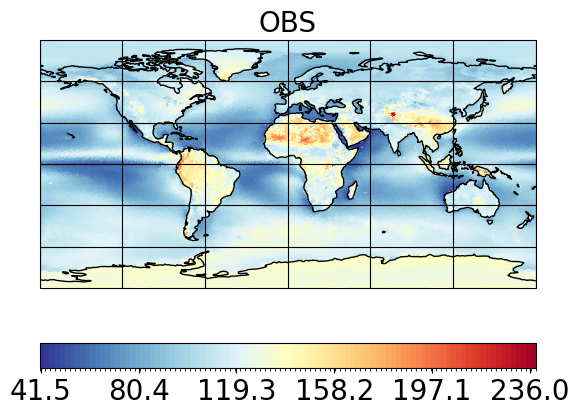

In [38]:
# Preprocess and load OBS data
# obs_avrg = preprocess_obs('rsut')
obs_avrg = xr.open_dataset("/home/b/b309170/bd1179_work/from_esmvaltool/OBS_ESACCI-CLOUD_sat_AVHRR-AMPM-fv3.0_Amon_rsut_198201-201612_r2b5.nc").rsut[0] 

# Load some 2D nc-file as a template for plotting
icon_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments'
file_nc = icon_path + '/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly_atm_2d_ml_19790501T000000Z.nc'
file_template = xr.open_dataset(file_nc)

# Coordinates are not fully recognized by xarray so that we have to add some manually 
coordlist = ["vertices_latitude", "vertices_longitude", "clat_bnds", "clon_bnds"]
file_template = file_template.set_coords([coord for coord in file_template.data_vars if coord in coordlist])

# Plot LW radiation
file_template.clt.values[0] = obs_avrg
psy.plot.mapplot(file_template, name='clt', time = [0], title='OBS', cmap='RdYlBu_r', grid_labels = 0, titlesize=20, bounds = set_bounds(obs_avrg), cticks=set_cticks(obs_avrg), grid_labelsize=15, cticksize=20)

cdo    remapcon: YAC first order conservative weights from lonlat (720x360) to unstructured (81920) grid
cdo    remapcon: YAC first order conservative weights from lonlat (360x180) to unstructured (81920) grid, with source mask (64788)


/tmp/ipykernel_1050792/3539143886.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  icona_rsut_data = xr.open_mfdataset(data_path + '*atm_2d_ml*.nc').rsut[2:]


100.4822
RMSE = 14.6407


psyplot.project.Project([    arr73: 1-dim DataArray of clt, with (ncells)=(81920,), time=1.979e+07])

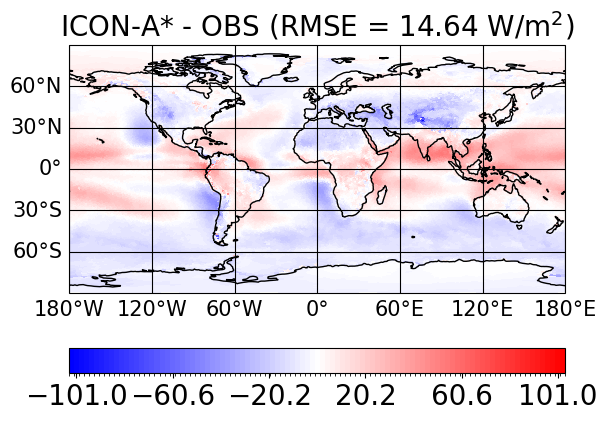

In [41]:
# Preprocess and load OBS data
obs_avrg = preprocess_obs('rsut')

# Load ICON-A-MLe data
data_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_icona_from_iconaml_20yrs_240927/'

icona_rsut_data = xr.open_mfdataset(data_path + '*atm_2d_ml*.nc').rsut[2:]
icona_rsut_data_avrg = icona_rsut_data.mean('time')

# Load some 2D nc-file as a template for plotting
icon_path = '/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments'
file_nc = icon_path + '/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly/ag_atm_amip_r2b5_cvtfall_entrmid_crt_05_3hourly_atm_2d_ml_19790501T000000Z.nc'
file_template = xr.open_dataset(file_nc)

# Coordinates are not fully recognized by xarray so that we have to add some manually 
coordlist = ["vertices_latitude", "vertices_longitude", "clat_bnds", "clon_bnds"]
file_template = file_template.set_coords([coord for coord in file_template.data_vars if coord in coordlist])

# Plot LW radiation
file_template.clt.values[0] = icona_rsut_data_avrg - obs_avrg
rmse = np.sqrt(np.mean((file_template.clt.values[0])**2))
print(np.max(np.abs(file_template.clt.values[0])))
print('RMSE = %.4f'%rmse)
psy.plot.mapplot(file_template, name='clt', time = [0], title=r'ICON-A* - OBS (RMSE = %.2f W/m$^2$)'%rmse, cmap='bwr', bounds = np.linspace(-104,104,100), \
                 cticks=set_cticks(icona_rsut_data_avrg - obs_avrg, div=True), titlesize=20, grid_labelsize=15, cticksize=20)

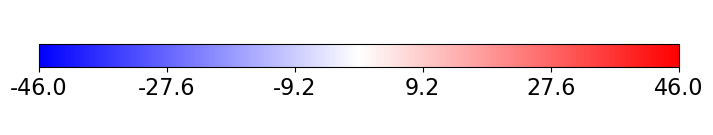

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
import numpy as np

fig, ax = plt.subplots(figsize=(8, 1.5))
cax = fig.add_axes([0.1, 0.5, 0.8, 0.15]) # [left, bottom, width, height]

cmap = plt.cm.bwr
vmin = -46.0
vmax = 46.0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# The ticks are exactly what's in your image
ticks = np.linspace(vmin, vmax, 6) 

cbar = mcolorbar.ColorbarBase(cax, 
                              cmap=cmap,
                              norm=norm,
                              orientation='horizontal',
                              ticks=ticks,
                              format='%.1f') # Format to one decimal

cbar.ax.tick_params(labelsize=16)
ax.axis('off') # Turn off the unused axes
plt.show()